
<div dir=ltr align=center>

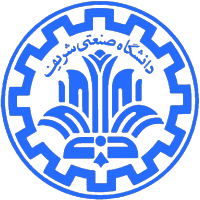

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Computer Vision: CNN Finetuning<br>
<font color=696880 size=4>
Prepared by Mohammad Amanlou

____

In [7]:
'Student Name' = 'Mobina Poulaei'
'Student ID' = '403206962'

Image classification is a key task in computer vision, but raw images often need preparation before training a model. Differences in size, lighting, and angles can confuse the model and hurt its performance. In this project, you’ll use the Flowers Multiclass Dataset from Kaggle to classify flower species. Preprocessing ensures all images are in a consistent format, which helps the model learn effectively. Data augmentation creates more varied training examples, making the model better at handling new images. You’ll build a VGG-style CNN from scratch and fine-tune a pretrained ResNet, comparing how these approaches affect accuracy and reliability.


## Learning Objectives
- Load a real-world **multiclass** image dataset (Flowers) and prepare **train/val/test** splits.
- Implement **preprocessing** (resize, normalization) and **data augmentation** (rotations, flips, crops, brightness/contrast).
- Build and train a **VGG-style CNN** from scratch.
- **Fine-tune ResNet50** in stages: (1) freeze base + train head; (2) unfreeze last block; (3) unfreeze all.
- Evaluate with **accuracy, precision, recall, F1**, plus **confusion matrix** and **ROC/AUC**.
- Compare VGG vs ResNet, discuss **generalization** and **reliability**.

In [8]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize

## 📍 Design a CNN Model to Classify Flower Species Images

### 📤 1. Dataset Loading


- **Dataset**: Flowers Multiclass (Kaggle) — *alsaniipe/flowers-multiclass-datasets*

- **Architectures**: VGG, ResNet50 (pretrained ImageNet).

- **This notebook offers both PyTorch (primary) and TensorFlow (optional) scaffolds.** Use one.

Get the Flowers Multiclass Dataset from Kaggle and load it into your coding environment.

- Step 1: Sign up for a Kaggle account if you don’t have one. Go to the Flowers Recognition dataset page and click "Download," or use the Kaggle.
- Step 2: Unzip the downloaded file and load it into Python using PyTorch or TensorFlow.
- Step 3: If the dataset isn’t split, divide it into training (70%), validation (10%), and test (20%) sets.


In [9]:
# Download the dataset from Kaggle

path = kagglehub.dataset_download("alsaniipe/flowers-multiclass-datasets")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flowers-multiclass-datasets' dataset.
Path to dataset files: /kaggle/input/flowers-multiclass-datasets


In [12]:
!cp -r /kaggle/input/flowers-multiclass-datasets /content/flowers_dataset

In [13]:
# Load all train, validation, and test images from the dataset

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "flower_photos/train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "flower_photos/validation",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "flower_photos/test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 3540 files belonging to 5 classes.
Found 80 files belonging to 5 classes.
Found 50 files belonging to 5 classes.


In [14]:
# Show different classes of flowers in our dataset
class_names = train_ds.class_names

print("Flower classes:", class_names)

Flower classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [15]:
# Show the number of images in each class of flower

class_counts = collections.Counter()

for images, labels in train_ds.unbatch():
    label = labels.numpy()
    class_name = class_names[label]
    class_counts[class_name] += 1

print("Number of images in each flower class:")
for cls in class_names:
    print(f"{cls}: {class_counts[cls]}")

Number of images in each flower class:
daisy: 607
dandelion: 872
roses: 615
sunflowers: 673
tulips: 773


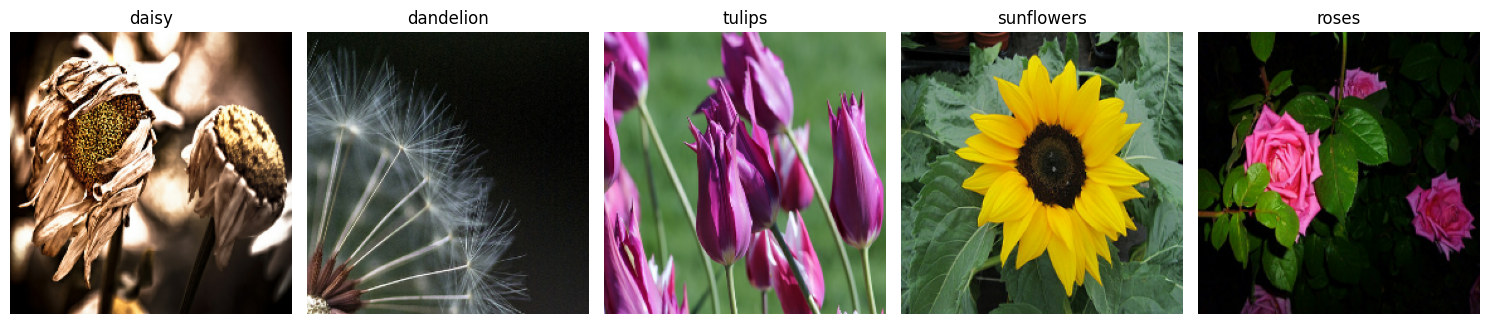

In [16]:
# Show a flower image from each class

plt.figure(figsize=(15, 8))

seen = set()
i = 1

for image, label in train_ds.unbatch():
    class_label = class_names[label.numpy()]

    if class_label not in seen:
        plt.subplot(1, len(class_names), i)
        plt.imshow(image.numpy().astype("uint8"))
        plt.title(class_label)
        plt.axis("off")

        seen.add(class_label)
        i += 1

    if len(seen) == len(class_names):
        break

plt.tight_layout()
plt.show()

### 🔄 Image Preprocessing & Data Augmentation

Before training, we need to prepare all images and labels in a consistent format:

### 🖼️ Image Preparation
- **Resize**: Adjust all images to **224 × 224 pixels** (standard for CNNs such as VGG or ResNet).  
- **Normalize**: Scale pixel values to the range **[0, 1]** by dividing to 255.  

### 🏷️ Label Preparation
Choose a label format and make sure it matches the loss function you use:

1. **One-hot encoding**  
   - Example: for class 2 of 5 → `[0, 0, 1, 0, 0]`  
   - Typically used with **categorical cross-entropy**.  

2. **Label encoding (class indices)**  
   - Example: classes represented as `0, 1, 2, ...`  
   - Works directly with **sparse categorical cross-entropy** or **CrossEntropyLoss** in PyTorch.  

👉 *Experiment with both formats to see which yields better performance.*


### 🔄 Data Augmentation

Apply augmentation **only to the training set** (not validation/test) to increase diversity and improve generalization.

### Suggested transforms
- **Random rotation**: between **−20° and +20°**
- **Horizontal flip**: with **50%** probability
- **Random crop / translation**: roughly **10%** of the image size
- **Slight brightness/contrast jitter**: small variations to simulate different lighting
- **(Optional) Other suitable transforms**: e.g., mild Gaussian noise, random zoom, color jitter, or small perspective/affine shifts

> **Tips:** Keep augmentations label-preserving and moderate, and leave validation/test images untouched for a fair evaluation.


Here, we **resize** all images to 224x224 pixels, because it is a common size for CNNs like VGG or ResNet. \
Also **normalize** them and scale pixel values to [0,1] by dividing by 255, because models perform better with smaller and normalized input values and also helps stabilize gradients during training, leading to more effective learning. \
For labels, we can choose a format between **label encoding** and **one-hot encoding**. We use one-hot encoding which no changes are needed.

Also we add variety to the **training set only**, so that the model learns patterns rather than memorizing the images, and can generalize better. So we apply some transformations like:
- Random rotations between -20° and 20°
- Horizontal flips with 50% chance
- Random crops (shifts) with 10% of image size
- Slight brightness or contrast changes with ±20%
- Zoom in with 90% to 110%

In [17]:
####################################################################
# Fill in missing code below (...),
# Hint: Apply the transformations according to the instructions given above
####################################################################
train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    shear_range=0.1,
    zoom_range=[0.9, 1.1],
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

validation_data = ImageDataGenerator(rescale=1./255)

test_data = ImageDataGenerator(rescale=1./255)

train_generator = train_data.flow_from_directory(
    "flower_photos/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_data.flow_from_directory(
    "flower_photos/validation",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_data.flow_from_directory(
    "flower_photos/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3540 images belonging to 5 classes.
Found 80 images belonging to 5 classes.
Found 50 images belonging to 5 classes.


### ⚙️ 4. Building a VGG CNN from Scratch

## Build & Train a VGG-Style CNN

### What is VGG?
**VGG** is a deep convolutional network composed of:
- Stacked **3×3 convolution** layers (small receptive fields, many channels)
- **Max-pooling** layers to downsample feature maps
- A **fully connected (FC)** head for classification at the end

> You can reference the classic **VGG-16** layout (Conv blocks → MaxPool → FC) or use the provided helper to speed up your implementation.

---

### Steps

1) **Define the Model**
   - Construct sequential **Conv→ReLU** blocks with **3×3 kernels** and **same padding**.
   - Insert **MaxPool (2×2, stride 2)** after each block to reduce spatial size.
   - Add a **classifier head** (Flatten → Dense/FC layers → Output layer with `num_classes`).

2) **Train on Augmented Data**
   - Use the **preprocessed (224×224, normalized)** images.
   - Apply **data augmentation** only to the **training set**.
   - Train for an appropriate number of **epochs** (monitor train/val curves).
   - Start with a baseline (e.g., **Adam**, `lr = 1e-3`, `batch_size = 32`) and adjust as needed.

3) **Evaluate on Validation**
   - Compute **accuracy**, **precision**, **recall**, and **F1** on the **validation set**.
   - Inspect the **confusion matrix** to see which classes are confused.
   - (Optional) Track **ROC/AUC** per class for deeper insight.

---

### Tips
- Keep the model **simple first**; deepen blocks later if underfitting.
- Use **early stopping** or **learning-rate scheduling** if overfitting/plateauing.
- Ensure the **loss function** matches your label format (one-hot vs class indices).


Now we can create and train a **VGG-style CNN**. \
VGG is a deep network with stacked convolutional layers (e.g., 3x3 filters), max-pooling layers, and fully connected layers at the end. bellow is the
VGG-16 architecture: \
(image from [geeksforgeeks](https://www.geeksforgeeks.org/vgg-16-cnn-model/))

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20200219152207/new41.jpg" alt="ERR" width="1000">

Here’s a breakdown of the VGG-16 architecture:

0. Input Layer:
    - A standard 254x254 image with 3 channels for RGBs.
1. Convolutional Layers (64 filters, 3×3 filters, same padding):
    - Two consecutive convolutional layers with 64 filters each and a filter size of 3×3.
    - Same padding is applied to maintain spatial dimensions.
2. Max Pooling Layer (2×2, stride 2):
    - Max-pooling layer with a pool size of 2×2 and a stride of 2.
3. Convolutional Layers (128 filters, 3×3 filters, same padding):
    - Two consecutive convolutional layers with 128 filters each and a filter size of 3×3.
4. Max Pooling Layer (2×2, stride 2):
    - Max-pooling layer with a pool size of 2×2 and a stride of 2.
5. Convolutional Layers (256 filters, 3×3 filters, same padding):
    - Three consecutive convolutional layers with 256 filters each and a filter size of 3×3.
6. Max Pooling Layer (2×2, stride 2):
    - Max-pooling layer with a pool size of 2×2 and a stride of 2.
7. Convolutional Layers (512 filters, 3×3 filters, same padding):
    - Three sets of three consecutive convolutional layers with 512 filters each and a filter size of 3×3.
8. Max Pooling Layer (2×2, stride 2):
    - Max-pooling layer with a pool size of 2×2 and a stride of 2.
9. Convolutional Layers (512 filters, 3×3 filters, same padding):
    - Three sets of three consecutive convolutional layers with 512 filters each and a filter size of 3×3.
10. Max Pooling Layer (2×2, stride 2):
    - Max-pooling layer with a pool size of 2×2 and a stride of 2.
11. Flattening:
    - Flatten the output feature map.
12. Fully Connected Layers:
    - Three fully connected layers with ReLU activation.
    - First layer with input size 512 and output size 4096.
    - Second layer with input size 4096 and output size 4096.
    - Third layer with input size 4096 and output size 5, corresponding to the 5 classes in the Flowers dataset.
13. Softmax Layer:
    - Softmax activation is applied to the output of the third fully connected layer for classification.

First, we define our VGG-16 model from scratch.

In [18]:
def build_vgg_model(num_classes, input_shape=(224, 224, 3)):
    """
    Build a simplified VGG-style Convolutional Neural Network (CNN) model.

    Architecture outline:
        Input: image tensor

    Args:
        num_classes: int
            Number of output classes for the final classification layer.
        input_shape: tuple of int, optional
            Shape of the input image tensor in (height, width, channels) format.
            Default is (224, 224, 3), corresponding to standard RGB images.

    Returns:
        tensorflow.keras.models.Sequential
            A compiled VGG-style CNN model ready for training and evaluation.

    """
    ####################################################################
    # Fill in missing code below (...),
    # Hint: Define the layers according to the architecture given above
    ####################################################################
    model = Sequential([
        Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        Conv2D(64, (3, 3), padding='same', activation='relu'),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        Conv2D(128, (3, 3), padding='same', activation='relu'),
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(rate=0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model

Now we can train the model on our augmented training data for appropriate epochs.

In [19]:
model = build_vgg_model(num_classes=5)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,670,309 (197.11 MB)

 Trainable params: 51,670,309 (197.11 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stopping_vgg = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_checkpoint_vgg = ModelCheckpoint('best_vgg_model.keras', save_best_only=True, monitor='val_loss')

print("\tVGG training with Label Encoding")

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stopping_vgg, model_checkpoint_vgg]
)

model.load_weights('best_vgg_model.keras')

val_loss_vgg, val_acc_vgg = model.evaluate(validation_generator)

print(f"\nVGG final -> Validation Accuracy: {val_acc_vgg:.4f}, Validation Loss: {val_loss_vgg:.4f}")

	VGG training with Label Encoding


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 89s 634ms/step - accuracy: 0.3680 - loss: 1.4651 - val_accuracy: 0.5875 - val_loss: 1.0934
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 57s 514ms/step - accuracy: 0.5353 - loss: 1.1258 - val_accuracy: 0.6000 - val_loss: 0.9584
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 57s 516ms/step - accuracy: 0.5840 - loss: 1.0276 - val_accuracy: 0.6125 - val_loss: 0.9522
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 63s 564ms/step - accuracy: 0.6259 - loss: 0.9729 - val_accuracy: 0.7000 - val_loss: 0.7109
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 458ms/step - accuracy: 0.6678 - loss: 0.8536 - val_accuracy: 0.7250 - val_loss: 0.8034
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 463ms/step - accuracy: 0.6621 - loss: 0.8531 - val_accuracy: 0.7250 - val_loss: 0.7370
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 52s 465ms/step - accuracy: 0.6949 - loss: 0.7963 - val_accuracy: 0.7000 - val_loss: 0.7724
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 457ms/step - accuracy: 0.7068 - loss: 0

### 🛠️ 5. Fine-Tuning a Pretrained ResNet

## Fine-Tune a Pretrained ResNet (e.g., ResNet50)

Leverage a pretrained **ResNet50** and adapt it to flower classification with staged fine-tuning.

---

### 1) Setup
- **Load** a pretrained `ResNet50` (e.g., ImageNet weights).
- **Replace** the final classification layer(s) with a new head sized to `num_classes`.

---

### 2) Stage A — Freeze Base, Train Head (5–10 epochs)
- **Freeze** all convolutional layers (backbone).
- **Train only the new classifier head**.
- Purpose: let the head learn class boundaries without disturbing general features.

**Suggested settings:** `lr ≈ 1e-3`, optimizer **Adam**/**SGD**, standard augmentation on **train** only.

---

### 3) Stage B — Unfreeze Last Conv Block (5–10 epochs)
- **Unfreeze** the last convolutional block (e.g., `layer4` in PyTorch).
- **Train** the unfrozen block **together with** the classifier head.
- Purpose: adapt higher-level features to the flower domain.

**Suggested settings:** lower LR for the backbone (e.g., `backbone lr = 1e-4`, `head lr = 1e-3`).

---

### 4) Stage C — Unfreeze All (5–10 epochs)
- **Unfreeze the entire network** and fine-tune end-to-end.
- Purpose: subtle refinement across all layers for maximum performance.

**Suggested settings:** small global LR (e.g., `1e-4` or lower), consider **weight decay**, **LR scheduling**, **early stopping**.

---

### 5) Evaluate After Each Stage (on Validation)
- Report **Accuracy**, **Precision**, **Recall**, **F1-score**.
- Plot the **confusion matrix** to inspect class-wise errors.
- (Optional) Compute **ROC curves** (one-vs-rest) and **macro AUC**.

> **Notes**
> - Keep **validation/test** data **augmentation-free** for fair evaluation.
> - Use **class-balanced sampling** or **weighted loss** if classes are imbalanced.
> - Differential learning rates help: **smaller** for pretrained layers, **larger** for the new head.


**Fine-Tuning** means taking a pretrained model (like ResNet50 trained on a large dataset such as ImageNet) and adapting it to our own new dataset. This technique has three major benefits:
- **Resource Efficiency**: No need to train a model from scratch.

- **Learned General Features**: The network already understands edges, textures, shapes, and patterns.

- **High Accuracy with Limited Data**: Since much of the learning has already been done, even small datasets can perform well.

**ResNet50** is a deep network with over 23 million parameters. We use it as a feature extractor:
- **Base Model**: Includes all the convolutional blocks that extract features from the input.

- **Head**: A few dense (fully connected) layers that act as the final classifier. These are the layers we replace to match our target task.

#### I. Setup

At first, we load the ResNet50 model with pretrained ImageNet weights, but we remove its original classification head (i.e., the top fully-connected layers). We'll replace this head with a new classifier tailored to our flower dataset.

In [21]:
# Load the base model without the head layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### II. Freeze Base and Train Head

At this stage, we freeze all convolutional layers which means their weights won't be updated. Then replace the final layer(s) with a new classifier for flower classes for 5-10 epochs.
At this stage, we freeze all convolutional layers of ResNet50 so their weights do not get updated during training. We only train the newly added dense layers (the classification head) to adapt to the flower classes and let the model learn to map the general features already extracted by ResNet to our specific flower classes.

In [22]:
####################################################################
# Fill in missing code below (...),
####################################################################
# Freeze all layers of the base model
base_model.trainable = False

# Create a new head for flower classification
model_resNet = Sequential([base_model, GlobalAveragePooling2D(), Dense(256, activation='relu'), Dropout(0.5), Dense(5, activation='softmax')])

model_resNet.compile(optimizer=optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model_resNet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
early_stopping_resNet = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
model_checkpoint_resNet = ModelCheckpoint('best_resNet_model.keras', save_best_only=True, monitor='val_loss')

print("\tResNet training with Label Encoding")

# Train the head layer
history_resNet = model_resNet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping_resNet, model_checkpoint_resNet]
)

model_resNet.load_weights('best_resNet_model.keras')

val_loss_resNet, val_acc_resNet = model_resNet.evaluate(validation_generator)

print(f"\nResNet final -> Validation Accuracy: {val_acc_resNet:.4f}, Validation Loss: {val_loss_resNet:.4f}")

	ResNet training with Label Encoding
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 76s 570ms/step - accuracy: 0.2531 - loss: 1.7470 - val_accuracy: 0.3375 - val_loss: 1.4567
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 454ms/step - accuracy: 0.3280 - loss: 1.5208 - val_accuracy: 0.3500 - val_loss: 1.4521
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 447ms/step - accuracy: 0.3308 - loss: 1.5225 - val_accuracy: 0.4000 - val_loss: 1.4678
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 450ms/step - accuracy: 0.3296 - loss: 1.5234 - val_accuracy: 0.4500 - val_loss: 1.4707
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 52s 463ms/step - accuracy: 0.3354 - loss: 1.5267 - val_accuracy: 0.4500 - val_loss: 1.4484
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 455ms/step - accuracy: 0.3341 - loss: 1.5286 - val_accuracy: 0.4000 - val_loss: 1.4286
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 454ms/step - accuracy: 0.3267 - loss: 1.5261 - val_accuracy: 0.3750 - val_loss: 1.4194
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 44

#### III. Unfreeze Last Convolutional Layer

Now, we unfreeze only the last ResNet layer. This layer is closer to the classifier and extracts more abstract, high-level features. We retrain this layer along with the classification head. So we allow the model to adjust the final extracted features to better match the nuances of our flower dataset, such as petal shape or texture.

In [24]:
# Unfreeze only the last (conv5_x) layer of the base model
for layer in base_model.layers:
    if 'conv5_block' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

model_resNet.compile(optimizer=optimizers.Adam(0.0001),  # lower learning rate for fine-tuning because of higher layers
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_resNet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 15,501,829 (59.13 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

In [25]:
early_stopping_resNet_2 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
model_checkpoint_resNet_2 = ModelCheckpoint('best_resNet_2_model.keras', save_best_only=True, monitor='val_loss')

print("\tResNet last layer training with Label Encoding")

history_resNet_2 = model_resNet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping_resNet_2, model_checkpoint_resNet_2]
)

model_resNet.load_weights('best_resNet_2_model.keras')

val_loss_resNet_2, val_acc_resNet_2 = model_resNet.evaluate(validation_generator)

print(f"\nResNet_2 final -> Validation Accuracy: {val_acc_resNet_2:.4f}, Validation Loss: {val_loss_resNet_2:.4f}")

	ResNet last layer training with Label Encoding
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 85s 602ms/step - accuracy: 0.3362 - loss: 1.9497 - val_accuracy: 0.3750 - val_loss: 1.4613
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 453ms/step - accuracy: 0.4847 - loss: 1.2914 - val_accuracy: 0.2125 - val_loss: 1.7735
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 456ms/step - accuracy: 0.5463 - loss: 1.1673 - val_accuracy: 0.4375 - val_loss: 1.8919
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 454ms/step - accuracy: 0.5864 - loss: 1.0997 - val_accuracy: 0.2000 - val_loss: 5.2098
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 455ms/step - accuracy: 0.6049 - loss: 1.0518 - val_accuracy: 0.3500 - val_loss: 3.0194
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 57s 517ms/step - accuracy: 0.6172 - loss: 0.9933 - val_accuracy: 0.5875 - val_loss: 0.9669
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 455ms/step - accuracy: 0.6202 - loss: 0.9883 - val_accuracy: 0.4125 - val_loss: 2.8760
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━

#### IV. Unfreeze the Entire Network

In the final step, we unfreeze all layers of ResNet and fine-tune the entire model using a low learning rate to avoid destroying previously learned representations. So we fully adapt the pretrained network to the new dataset, allowing it to learn both low-level and high-level domain-specific features.

In [26]:
# Unfreeze the total base model for final training
base_model.trainable = True

# Compile again
model_resNet.compile(optimizer=optimizers.Adam(0.00001),  # even lower learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_resNet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 24,060,421 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [27]:
early_stopping_resNet_3 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
model_checkpoint_resNet_3 = ModelCheckpoint('best_resNet_3_model.keras', save_best_only=True, monitor='val_loss')

print("\tResNet last layer training with Label Encoding")

history_resNet_3 = model_resNet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping_resNet_3, model_checkpoint_resNet_3]
)

model_resNet.load_weights('best_resNet_3_model.keras')

val_loss_resNet_3, val_acc_resNet_3 = model_resNet.evaluate(validation_generator)

print(f"\nResNet_3 final -> Validation Accuracy: {val_acc_resNet_3:.4f}, Validation Loss: {val_loss_resNet_3:.4f}")

	ResNet last layer training with Label Encoding
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 149s 828ms/step - accuracy: 0.3444 - loss: 3.8125 - val_accuracy: 0.2000 - val_loss: 3.3039
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 66s 591ms/step - accuracy: 0.7205 - loss: 0.8103 - val_accuracy: 0.2125 - val_loss: 3.2654
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 65s 587ms/step - accuracy: 0.7917 - loss: 0.5728 - val_accuracy: 0.2750 - val_loss: 2.3616
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 66s 592ms/step - accuracy: 0.8353 - loss: 0.4534 - val_accuracy: 0.2875 - val_loss: 1.6717
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 63s 567ms/step - accuracy: 0.8572 - loss: 0.3869 - val_accuracy: 0.5250 - val_loss: 1.2117
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 63s 569ms/step - accuracy: 0.8915 - loss: 0.3053 - val_accuracy: 0.7750 - val_loss: 0.6980
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 64s 571ms/step - accuracy: 0.9048 - loss: 0.2639 - val_accuracy: 0.8375 - val_loss: 0.4698
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━

### 📈 6. Result Comparison

## Fair Comparison — VGG vs. ResNet

To compare the two models **fairly**, keep the evaluation protocol identical.

### Experimental Controls
- **Same data splits**: fixed `train/val/test` (seeded and reusable).
- **Same preprocessing**: resize to **224×224**, identical normalization.
- **Augmentation**: apply **only to training**; keep val/test clean.
- **Batching & loaders**: same `batch_size`, shuffling policy, workers.
- **Training policy**: comparable epochs, early stopping criteria, and learning-rate schedules.
- **Randomness**: fix seeds (or **run ≥3 seeds** and report mean ± std).

---

### Metrics to Report
- **Accuracy** (overall)
- **Precision, Recall, F1-score**  
  - Report **per-class** and **macro-averaged** (and optionally **weighted**/**micro**).
- Present a **compact table** for each model on the **validation** (and test) set.

> *Macro averages* treat all classes equally; *weighted* averages account for class frequency.

---

### Confusion Matrices
- Plot confusion matrices (with `matplotlib` or `seaborn`) **for each model**.
- Include:
  - **Counts** (raw) and/or **normalized** by true class.
  - Clear class labels and a colorbar.
- Use them to analyze **where** each model confuses classes.

---

### ROC Curves & AUC (Multiclass)
- Compute **one-vs-rest ROC** curves per class for **each model**.
- Report:
  - **Per-class AUC**
  - **Macro AUC** (average across classes)
  - *(Optional)* **Micro AUC**
- **Interpretation**  
  - **ROC curve** plots **TPR** (true positive rate) vs. **FPR** (false positive rate) at varying thresholds, illustrating a classifier’s diagnostic ability.  
  - **AUC** (Area Under the Curve) summarizes ROC as a single value in **[0, 1]**; **higher** indicates **better discrimination**.

> Tip: For **class imbalance**, also consider **Precision–Recall (PR) curves** and **macro/weighted F1** alongside ROC/AUC.

---

### Reporting Template (Example)
- **VGG (Validation)**: Accuracy, Macro P/R/F1, per-class P/R/F1, Confusion Matrix, Per-class ROC + Macro AUC  
- **ResNet (Validation)**: Accuracy, Macro P/R/F1, per-class P/R/F1, Confusion Matrix, Per-class ROC + Macro AUC  
- **Summary**: side-by-side bar charts (Accuracy, Macro F1, Macro AUC), brief discussion of strengths/weaknesses.


First, we should predicts the labels on both of our models.

In [28]:
####################################################################
# Fill in missing code below (...),
####################################################################

y_true_vgg = []
y_pred_vgg = []
y_prob_vgg = []

for images, labels in test_generator:
    preds = model.predict(images)
    y_true_vgg.extend(np.argmax(labels, axis=1))
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_prob_vgg.extend(preds)

    if len(y_true_vgg) >= test_generator.samples:
        break

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)
y_prob_vgg = np.array(y_prob_vgg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [29]:
# Predict labels of the test for RestNet

y_true_restNet = []
y_pred_restNet = []
y_prob_restNet = []

for images, labels in test_generator:
    preds = model_resNet.predict(images)
    y_true_restNet.extend(np.argmax(labels, axis=1))
    y_pred_restNet.extend(np.argmax(preds, axis=1))
    y_prob_restNet.extend(preds)

    if len(y_true_restNet) >= test_generator.samples:
        break

y_true_restNet = np.array(y_true_restNet)
y_pred_restNet = np.array(y_pred_restNet)
y_prob_restNet = np.array(y_prob_restNet)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


Now we can calculate these metrics:
- **Accuracy** -> The percentage of correct predictions out of all predictions.

$$ Accuracy = \dfrac{TP + TN}{TP + TN + FP + FN} \times 100 $$

- **Precision** -> The percentage of positive predictions that are actually correct. It is about how reliable the positive predictions are.

$$ Precision = \dfrac{TP}{TP + FP} \times 100 $$

- **Recall** -> The percentage of actual positives that are correctly identified. It is about how many actual positives the model successfully captures.

$$ Recall = \dfrac{TP}{TP + FN} \times 100 $$

- **F1-Score** -> The harmonic mean of Precision and Recall. It is useful when we want a balance between Precision and Recall, especially with imbalanced data.

$$ F1 Score = 2 \times \dfrac{Precision \times Recall}{Precision + Recall} $$

Where *TP* is true positive, *TN* is true negative, *FP* is false positive and *FN* is false negative.

In [30]:
print("\n\tVGG Classification Report:")
print("Accuracy:", accuracy_score(y_true_vgg, y_pred_vgg))
print("Precision:", precision_score(y_true_vgg, y_pred_vgg, average='macro'))
print("Recall:", recall_score(y_true_vgg, y_pred_vgg, average='macro'))
print("F1 Score:", f1_score(y_true_vgg, y_pred_vgg, average='macro'))

print("\n\tRestNet Classification Report:")
print("Accuracy:", accuracy_score(y_true_restNet, y_pred_restNet))
print("Precision:", precision_score(y_true_restNet, y_pred_restNet, average='macro'))
print("Recall:", recall_score(y_true_restNet, y_pred_restNet, average='macro'))
print("F1 Score:", f1_score(y_true_restNet, y_pred_restNet, average='macro'))


	VGG Classification Report:
Accuracy: 0.78
Precision: 0.7651948051948052
Recall: 0.78
F1 Score: 0.7684033613445378

	RestNet Classification Report:
Accuracy: 0.82
Precision: 0.8457875457875458
Recall: 0.82
F1 Score: 0.8236811512622524


Then, we plot confusion matrices for both models.

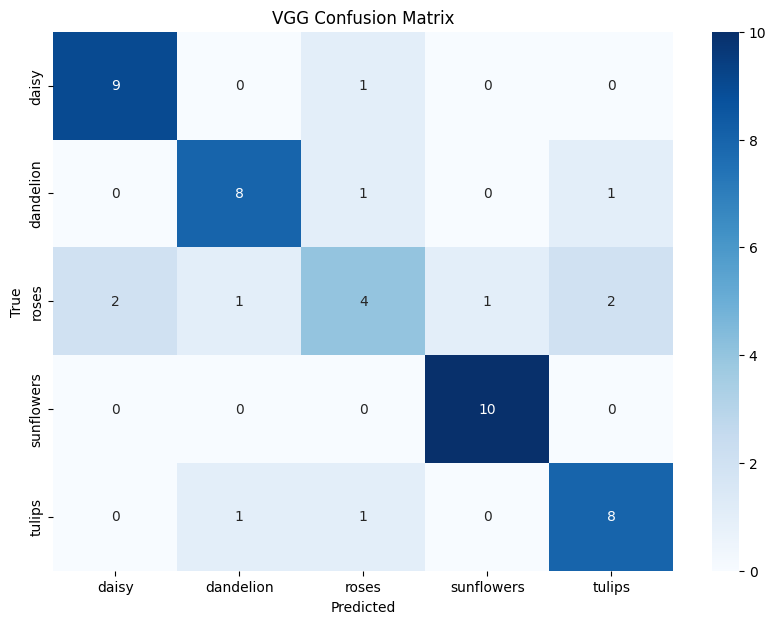

In [31]:
cm = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("VGG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

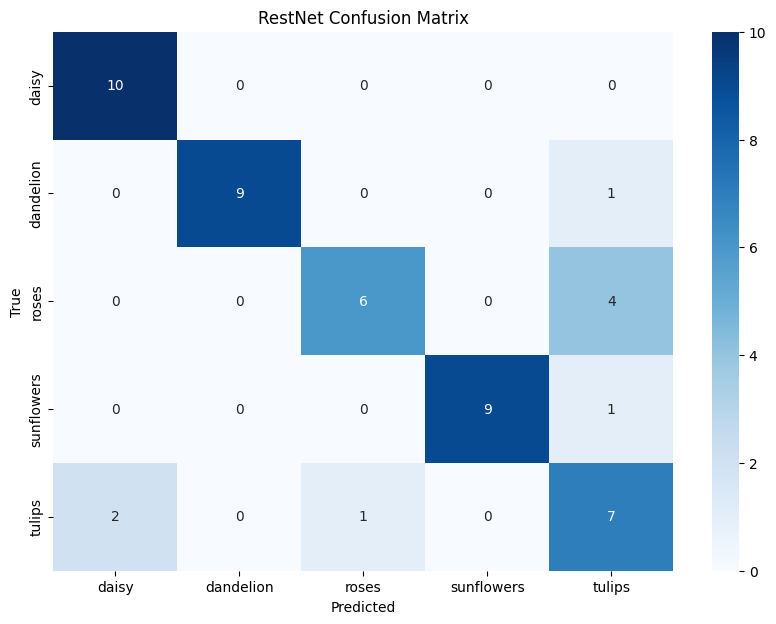

In [32]:
cm = confusion_matrix(y_true_restNet, y_pred_restNet)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("RestNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Then, we plot ROC (Receiver Operating Characteristic) curves for deeper insights. Also we calculate the AUC (Area Under
the Curve) score for each model.
- **ROC** -> Illustrates the diagnostic ability of a binary classifier by plotting the true positive rate against the false positive rate at various threshold settings.
- **AUC** -> Quantifies the overall performance of the classifier as a single value between 0 and 1, where a higher value indicates better discrimination ability.

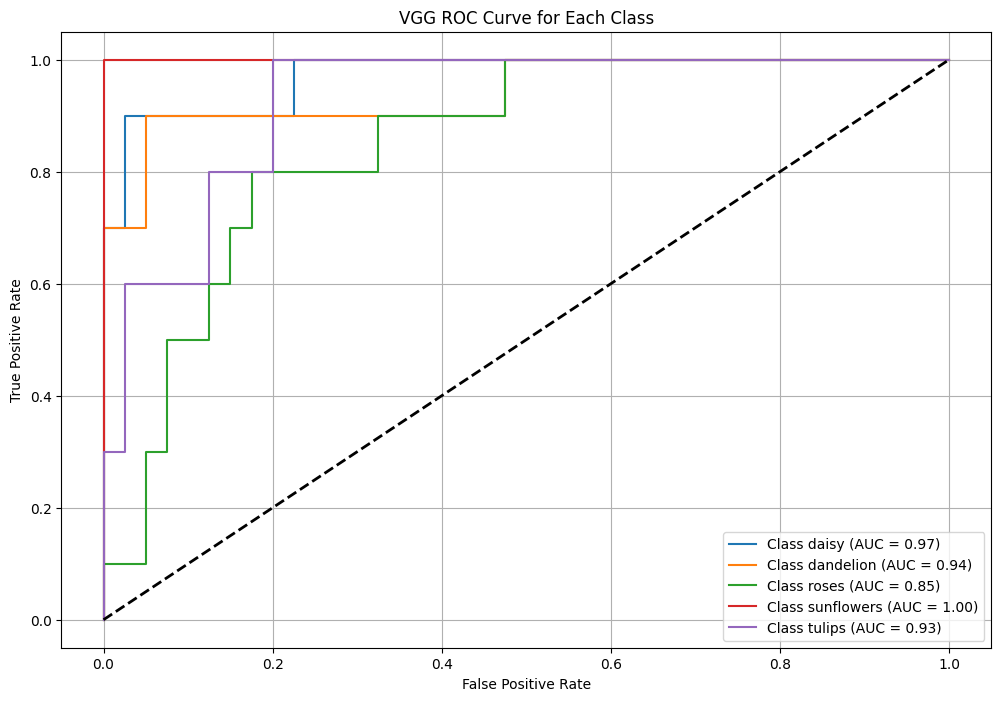

VGG Mean AUC: 0.9385


In [33]:
y_true_bin_vgg = label_binarize(y_true_vgg, classes=range(len(class_names)))

fpr_vgg = dict()
tpr_vgg = dict()
roc_auc_vgg = dict()

for i in range(len(class_names)):
    fpr_vgg[i], tpr_vgg[i], _ = roc_curve(y_true_bin_vgg[:, i], y_prob_vgg[:, i])
    roc_auc_vgg[i] = auc(fpr_vgg[i], tpr_vgg[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
for i in range(len(class_names)):
    plt.plot(fpr_vgg[i], tpr_vgg[i], label=f"Class {class_names[i]} (AUC = {roc_auc_vgg[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG ROC Curve for Each Class")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Macro-average AUC
macro_auc_vgg = np.mean(list(roc_auc_vgg.values()))
print(f"VGG Mean AUC: {macro_auc_vgg:.4f}")

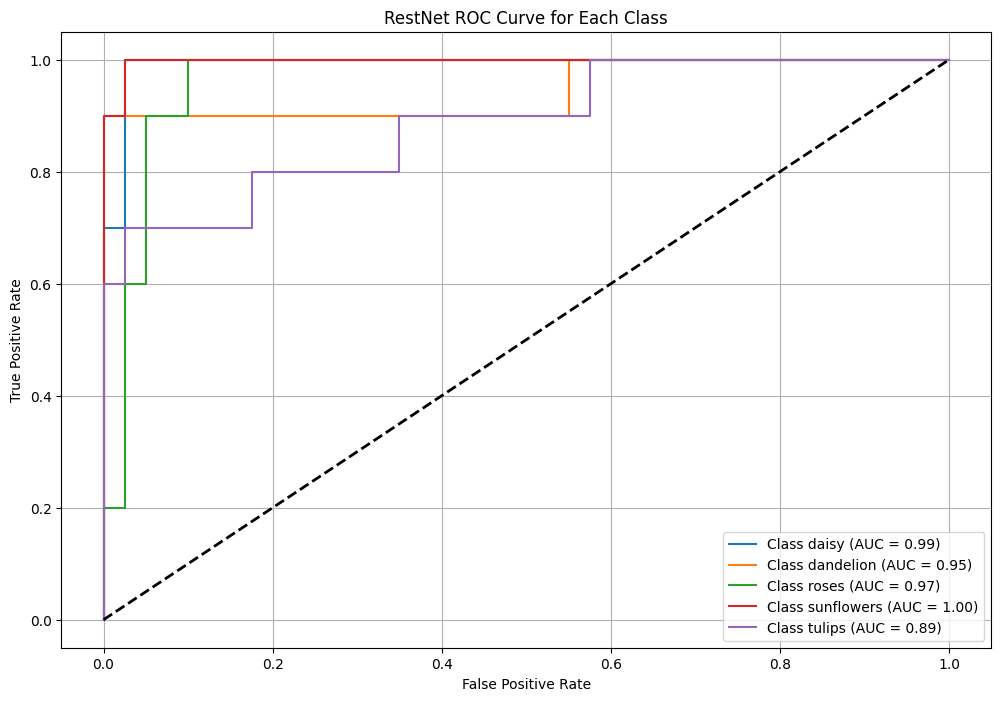

RestNet Mean AUC: 0.9575


In [34]:
y_true_bin_restNet = label_binarize(y_true_restNet, classes=range(len(class_names)))

fpr_restNet = dict()
tpr_restNet = dict()
roc_auc_restNet = dict()

for i in range(len(class_names)):
    fpr_restNet[i], tpr_restNet[i], _ = roc_curve(y_true_bin_restNet[:, i], y_prob_restNet[:, i])
    roc_auc_restNet[i] = auc(fpr_restNet[i], tpr_restNet[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
for i in range(len(class_names)):
    plt.plot(fpr_restNet[i], tpr_restNet[i], label=f"Class {class_names[i]} (AUC = {roc_auc_restNet[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RestNet ROC Curve for Each Class")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Macro-average AUC
macro_auc_restNet = np.mean(list(roc_auc_restNet.values()))
print(f"RestNet Mean AUC: {macro_auc_restNet:.4f}")

### 🚀 Questions

***Suppose you have a CNN that begins by taking an input image of size 28 × 28 × 3 and passing through a convolution layer that convolves the image using 3 filters of dimensions 2 × 2 × 3 with valid padding.***

***A. How many learnable parameters does this convolution layer have?***

First we specify these metrics from question:

- $H_{in} = 28$
- $W_{in} = 28$
- $C_{in} = 3$ for RGB
- $K = 3$
- $F_h = 2$
- $F_w = 2$
- $F_c = 3$
- No padding

Now we compute learnable parameters for this layer, which consists of weights and biases:
- **Weights per filter** = $F_h \times F_w \times F_c$ = 2 $\times$ 2 $\times$ 3 = 12
- **Bias per filter** = 1

So:
- **Total parameters per filter** = Weights per filter + Bias per filter = 12 + 1 = 13

As a result:
- **Total learnable parameters** = K $\times$ Total parameters per filter = 3 $\times$ 13 = ***39***

***B. Suppose that you instead decided to use a fully connected layer to replicate the behavior of this convolutional layer. How many parameters would that fully connected layer have?***

First we compute dimensions of the output with stride = 1 and padding = 0:

- $H_{out} = (H_{in} - F_h + 2p) / S + 1$ = (28 - 2 + 0) / 1 + 1 = 27
- $W_{out} = (W_{in} - F_w + 2p) / S + 1$ = (28 - 2 + 0) / 1 + 1 = 27
- $C_{out} = K$ = 3

So:
- **Number of output layer neurons** = $H_{out} \times $W_{out} \times $C_{out}$ = 27 $\times$ 27 $\times$ 3 = 2187

Also:
- **Number of input layer neurons** = $H_{in} \times $W_{in} \times $C_{in}$ = 28 $\times$ 28 $\times$ 3 = 2352

Then:
- **Number of weights** = Number of input layer neurons $\times$ Number of output layer neurons = 2352 $\times$ 2187 = 5143824

And we know that:
- **Number of biases** = Number of output layer neurons = 2187

As a result:
- **Total learnable parameters** = Number of weights + Number of biases = 5143824 + 2187 = ***5146011***